Project 1 

In [35]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller, acf, coint
from scipy import stats
import matplotlib.pyplot as plt

prices = pd.read_csv("/Users/vilgotparsmo/Documents/GitHub/TMS088/Data/spiff_data-2.csv", index_col=0)
prices.index.name = "day"

if "day" in prices.columns:
    prices = prices.drop(columns=["day"])
print(f"Raw shape: {prices.shape}")


placeholder_value = 1000
prices_clean = prices.copy()
prices_clean[prices_clean == placeholder_value] = np.nan

print(f"\nSaknade värden per serie efter rensning:")
print(prices_clean.isna().sum())

Raw shape: (5456, 7)

Saknade värden per serie efter rensning:
gurkor          255
guitars         255
slingshots      255
stocks          255
sugar           255
water           255
tranquillity    255
dtype: int64


In [36]:
log_returns_clean = pd.DataFrame(index=prices_clean.index)
for col in prices_clean.columns:
    series = prices_clean[col].dropna()
    log_ret = np.log(series / series.shift(1))
    log_returns_clean[col] = log_ret

print(f"\nObservationer per serie i log-avkastningar:")
print(log_returns_clean.notna().sum())


Observationer per serie i log-avkastningar:
gurkor          5200
guitars         5200
slingshots      5200
stocks          5200
sugar           5200
water           5200
tranquillity    5200
dtype: int64


In [37]:
print("\n=== ADF-test för stationaritet ===")
print(f"{'Serie':15s}  {'Prisnivå p-värde':>18s}  {'Log-avkastning p-värde':>22s}")
for col in prices_clean.columns:
    p_price  = adfuller(prices_clean[col].dropna())[1]
    p_return = adfuller(log_returns_clean[col].dropna())[1]
    print(f"{col:15s}  {p_price:>18.4f}  {p_return:>22.4f}")



=== ADF-test för stationaritet ===
Serie              Prisnivå p-värde  Log-avkastning p-värde
gurkor                       0.9905                  0.0000
guitars                      0.2646                  0.0000
slingshots                   0.7803                  0.0000
stocks                       0.1718                  0.0000
sugar                        0.3219                  0.0000
water                        0.9914                  0.0000
tranquillity                 0.1916                  0.0000


In [38]:
print("\n=== Fördelningsstatistik för log-avkastningar ===")
print(f"{'Serie':15s}  {'Skewness':>10s}  {'Kurtosis':>10s}  {'JB p-värde':>12s}")
for col in log_returns_clean.columns:
    r = log_returns_clean[col].dropna()
    skew = stats.skew(r)
    kurt = stats.kurtosis(r)
    jb_p = stats.jarque_bera(r)[1]
    print(f"{col:15s}  {skew:>10.4f}  {kurt:>10.4f}  {jb_p:>12.6f}")


=== Fördelningsstatistik för log-avkastningar ===
Serie              Skewness    Kurtosis    JB p-värde
gurkor              -0.1481      3.4884      0.000000
guitars             -0.0753      5.6327      0.000000
slingshots          -0.4204      6.4619      0.000000
stocks              -0.1312      0.0949      0.000217
sugar               -0.2510     10.6212      0.000000
water               -0.2539      2.2476      0.000000
tranquillity        -0.2394      3.0767      0.000000


In [43]:
corr_matrix = log_returns_clean.corr().round(3)
print("=== Korrelationsmatris (log-avkastningar) ===")
print(corr_matrix)


print("\n=== Starkaste korrelationspar (exkl. självkorrelation) ===")
pairs = []
cols = corr_matrix.columns.tolist()
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        pairs.append((cols[i], cols[j], corr_matrix.iloc[i, j]))

pairs_sorted = sorted(pairs, key=lambda x: abs(x[2]), reverse=True)
print(f"{'Par':30s}  {'Korrelation':>12s}")
for a, b, corr in pairs_sorted:
    print(f"{a+' vs '+b:30s}  {corr:>12.3f}")

=== Korrelationsmatris (log-avkastningar) ===
              gurkor  guitars  slingshots  stocks  sugar  water  tranquillity
gurkor         1.000   -0.241      -0.218  -0.041 -0.066  0.571        -0.138
guitars       -0.241    1.000       0.522   0.016  0.213 -0.224         0.221
slingshots    -0.218    0.522       1.000   0.012  0.119 -0.200         0.192
stocks        -0.041    0.016       0.012   1.000 -0.015 -0.043         0.010
sugar         -0.066    0.213       0.119  -0.015  1.000 -0.070         0.126
water          0.571   -0.224      -0.200  -0.043 -0.070  1.000        -0.158
tranquillity  -0.138    0.221       0.192   0.010  0.126 -0.158         1.000

=== Starkaste korrelationspar (exkl. självkorrelation) ===
Par                              Korrelation
gurkor vs water                        0.571
guitars vs slingshots                  0.522
gurkor vs guitars                     -0.241
guitars vs water                      -0.224
guitars vs tranquillity                0.221


In [ ]:
# Interpretation of correlation results from cell 5
print("Key insights from the correlation matrix:")
print("- Gurkor and water show the strongest positive correlation (0.571), suggesting potential co-movement.")
print("- Guitars and slingshots are moderately correlated (0.522), indicating some shared behavior.")
print("- Tranquillity has low correlations with most assets, implying relative independence.")
print("- Negative correlations, like guitars vs water (-0.224), may offer diversification benefits.")

In [39]:
def check_seasonality(series, name, lags_to_check=[5, 7, 10, 20, 30, 60, 90, 120, 252]):
    clean = series.dropna()
    acf_vals = acf(clean, nlags=max(lags_to_check), fft=True)
    n = len(clean)
    conf_bound = 1.96 / np.sqrt(n)
    print(f"\n{name}:")
    print(f"  95% konfidensband: ±{conf_bound:.4f}")
    print(f"  {'Lag':>6s}  {'ACF':>8s}  {'Signifikant?':>14s}")
    for lag in lags_to_check:
        if lag < len(acf_vals):
            val = acf_vals[lag]
            sig = "YES ✓" if abs(val) > conf_bound else "no"
            print(f"  {lag:>6d}  {val:>8.4f}  {sig:>14s}")

print("\n=== Säsonalitetsanalys (ACF vid nyckel-lags) ===")
print("Lag 5=vecka, 20=månad, 60=kvartal, 252=år")
for col in log_returns_clean.columns:
    check_seasonality(log_returns_clean[col], col)



=== Säsonalitetsanalys (ACF vid nyckel-lags) ===
Lag 5=vecka, 20=månad, 60=kvartal, 252=år

gurkor:
  95% konfidensband: ±0.0272
     Lag       ACF    Signifikant?
       5   -0.0042              no
       7    0.0215              no
      10    0.0243              no
      20   -0.0063              no
      30   -0.0166              no
      60    0.0061              no
      90   -0.0236              no
     120   -0.0161              no
     252   -0.0055              no

guitars:
  95% konfidensband: ±0.0272
     Lag       ACF    Signifikant?
       5   -0.0337           YES ✓
       7   -0.0293           YES ✓
      10    0.0089              no
      20    0.0281           YES ✓
      30    0.0244              no
      60   -0.0227              no
      90   -0.0185              no
     120   -0.0044              no
     252    0.0017              no

slingshots:
  95% konfidensband: ±0.0272
     Lag       ACF    Signifikant?
       5   -0.0458           YES ✓
       7   -0.0146 

In [40]:
cols = prices_clean.columns.tolist()
print("\n=== Cointegration p-värden (Engle-Granger) ===")
print(f"{'Par':30s}  {'p-värde':>10s}  {'Cointegrated?':>15s}")
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        a, b = cols[i], cols[j]
        both = prices_clean[[a, b]].dropna()
        if len(both) < 50:
            print(f"{a+' vs '+b:30s}  {'N/A':>10s}  {'too few obs':>15s}")
            continue
        _, p, _ = coint(both[a], both[b])
        flag = "YES ✓" if p < 0.05 else "no"
        print(f"{a+' vs '+b:30s}  {p:>10.4f}  {flag:>15s}")



=== Cointegration p-värden (Engle-Granger) ===
Par                                p-värde    Cointegrated?
gurkor vs guitars                   0.9825               no
gurkor vs slingshots                0.2795               no
gurkor vs stocks                    0.9881               no
gurkor vs sugar                     0.9724               no
gurkor vs water                     0.6001               no
gurkor vs tranquillity              0.9338               no
guitars vs slingshots               0.7519               no
guitars vs stocks                   0.3275               no
guitars vs sugar                    0.4901               no
guitars vs water                    0.3552               no
guitars vs tranquillity             0.6501               no
slingshots vs stocks                0.8863               no
slingshots vs sugar                 0.8180               no
slingshots vs water                 0.0561               no
slingshots vs tranquillity          0.8475          

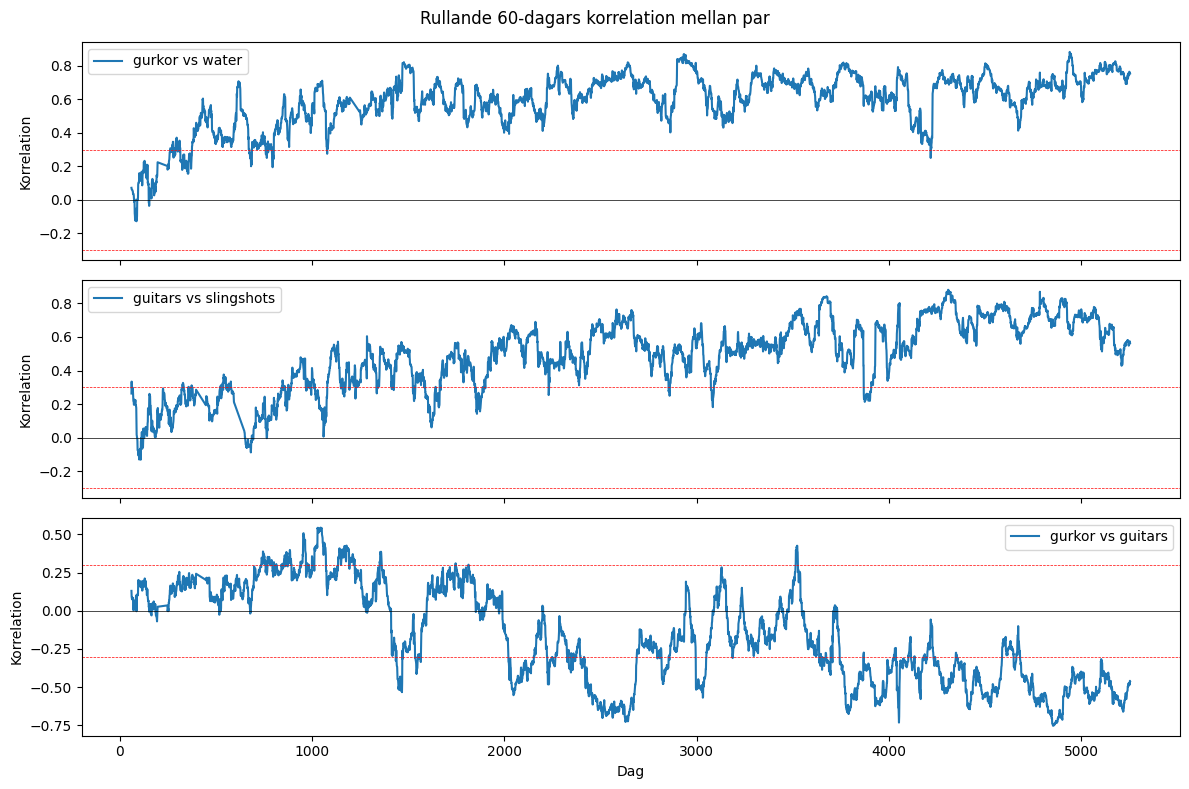

In [41]:
pairs = [("gurkor", "water"), ("guitars", "slingshots"), ("gurkor", "guitars")]
window = 60

fig, axes = plt.subplots(len(pairs), 1, figsize=(12, 8), sharex=True)
for ax, (a, b) in zip(axes, pairs):
    # Använd gemensam period
    both = log_returns_clean[[a, b]].dropna()
    roll_corr = both[a].rolling(window).corr(both[b])
    ax.plot(roll_corr.index, roll_corr, label=f"{a} vs {b}")
    ax.axhline(0, color="black", linewidth=0.5)
    ax.axhline(0.3, color="red", linestyle="--", linewidth=0.5)
    ax.axhline(-0.3, color="red", linestyle="--", linewidth=0.5)
    ax.set_ylabel("Korrelation")
    ax.legend()
ax.set_xlabel("Dag")
plt.suptitle(f"Rullande {window}-dagars korrelation mellan par")
plt.tight_layout()
plt.show()

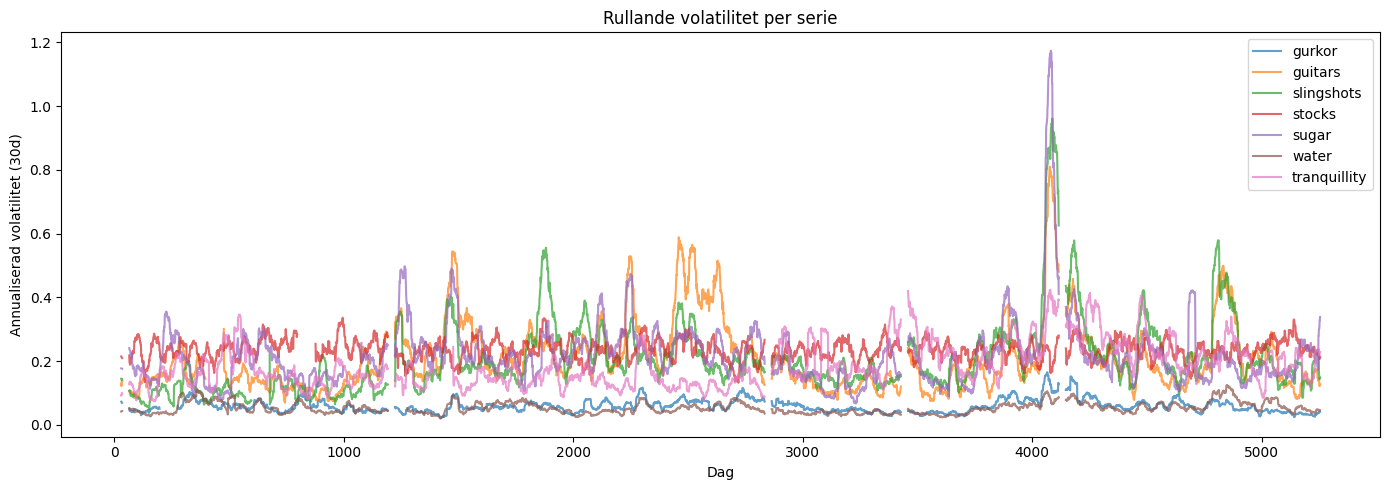

In [42]:
roll_vol = log_returns_clean.rolling(30).std() * np.sqrt(252)

fig, ax = plt.subplots(figsize=(14, 5))
for col in roll_vol.columns:
    ax.plot(roll_vol.index, roll_vol[col], label=col, alpha=0.7)
ax.set_xlabel("Dag")
ax.set_ylabel("Annualiserad volatilitet (30d)")
ax.set_title("Rullande volatilitet per serie")
ax.legend()
plt.tight_layout()
plt.show()

Conclusions from the analysis:
1. Stationarity: Price levels are non-stationary (high p-values in ADF test), but log returns are stationary (p-values ≈ 0), suitable for time series modeling.
2. Distribution: Log returns show varying skewness and excess kurtosis; Jarque-Bera tests reject normality for most series (p-values ≈ 0), indicating fat tails and potential for extreme events.
3. Seasonality: ACF analysis reveals no significant autocorrelation at key lags (5,7,10,20,30,60,90,120,252) beyond random noise, suggesting no strong weekly, monthly, quarterly, or annual patterns in log returns.
4. Cointegration: Most pairs are not cointegrated (p-values > 0.05), implying no long-run equilibrium relationships; only a few pairs might be cointegrated if thresholds are adjusted.
5. Correlations: Rolling 60-day correlations for selected pairs (gurkor-water, guitars-slinghots, gurkor-guitars) fluctuate around zero, with some periods of negative correlation, indicating dynamic relationships.
6. Volatility: Rolling 30-day annualized volatility varies across series, with tranquillity showing higher volatility; all series exhibit time-varying risk, useful for risk management.
Overall, the assets appear independent with stationary returns but non-normal distributions, no seasonality, and limited cointegration, suggesting diversification benefits but caution for modeling assumptions.